# Обработка пропусков в данных в датасете Iris  (Вариант 9)
## Ковалев Е.А. гр. ИУ5-66Б

## Импорт библиотек и загрузка данных

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import load_iris
np.random.seed(2026669)

iris = load_iris() 
df = pd.DataFrame(iris.data, columns=iris.feature_names) 
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names) 
df.head() 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Подготовка данных

В исходном датасете нет пропусков, а целевая переменная species уже является категориальным признаком. 
Создадим дополнительно категориальный признак на основе числового (petal length (cm)), а затем искусственно внесём пропуски в один количественный признак (sepal width (cm)) и в созданный категориальный признак.

In [2]:
 # Создаём категориальный признак на основе числового 
df['petal_size'] = pd.cut( df['petal length (cm)'], bins=[0, 2, 5, 10], labels=['small', 'medium', 'large'] ) 
df['petal_size'] = df['petal_size'].astype('object')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,petal_size
0,5.1,3.5,1.4,0.2,setosa,small
1,4.9,3.0,1.4,0.2,setosa,small
2,4.7,3.2,1.3,0.2,setosa,small
3,4.6,3.1,1.5,0.2,setosa,small
4,5.0,3.6,1.4,0.2,setosa,small


In [3]:
# Искусственно вносим пропуски (15% значений) в один количественный и один категориальный признак 
n = len(df) 
missing_idx_num = np.random.choice(df.index, size=int(n * 0.15), replace=False)
df.loc[missing_idx_num, 'sepal width (cm)'] = np.nan
missing_idx_cat = np.random.choice(df.index, size=int(n * 0.15), replace=False) 
df.loc[missing_idx_cat, 'petal_size'] = np.nan 
df.isna().sum() 

sepal length (cm)     0
sepal width (cm)     22
petal length (cm)     0
petal width (cm)      0
species               0
petal_size           22
dtype: int64

## Обработка пропусков

### Количественный признак: sepal width (cm)

Заполним пропуски медианой признака. Медиана устойчива к выбросам и хорошо подходит для числовых признаков.

In [4]:
median_value = df['sepal width (cm)'].median()
df['sepal width (cm)'] = df['sepal width (cm)'].fillna(median_value)
print(f'Медиана: {median_value}') 

Медиана: 3.0


### Категориальный признак: petal_size

In [5]:
mode_value = df['petal_size'].mode()[0]
df['petal_size'] = df['petal_size'].fillna(mode_value)
print(f'Мода: {mode_value}')

Мода: medium


In [6]:
df.isna().sum() 

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
petal_size           0
dtype: int64

## Парные диаграммы

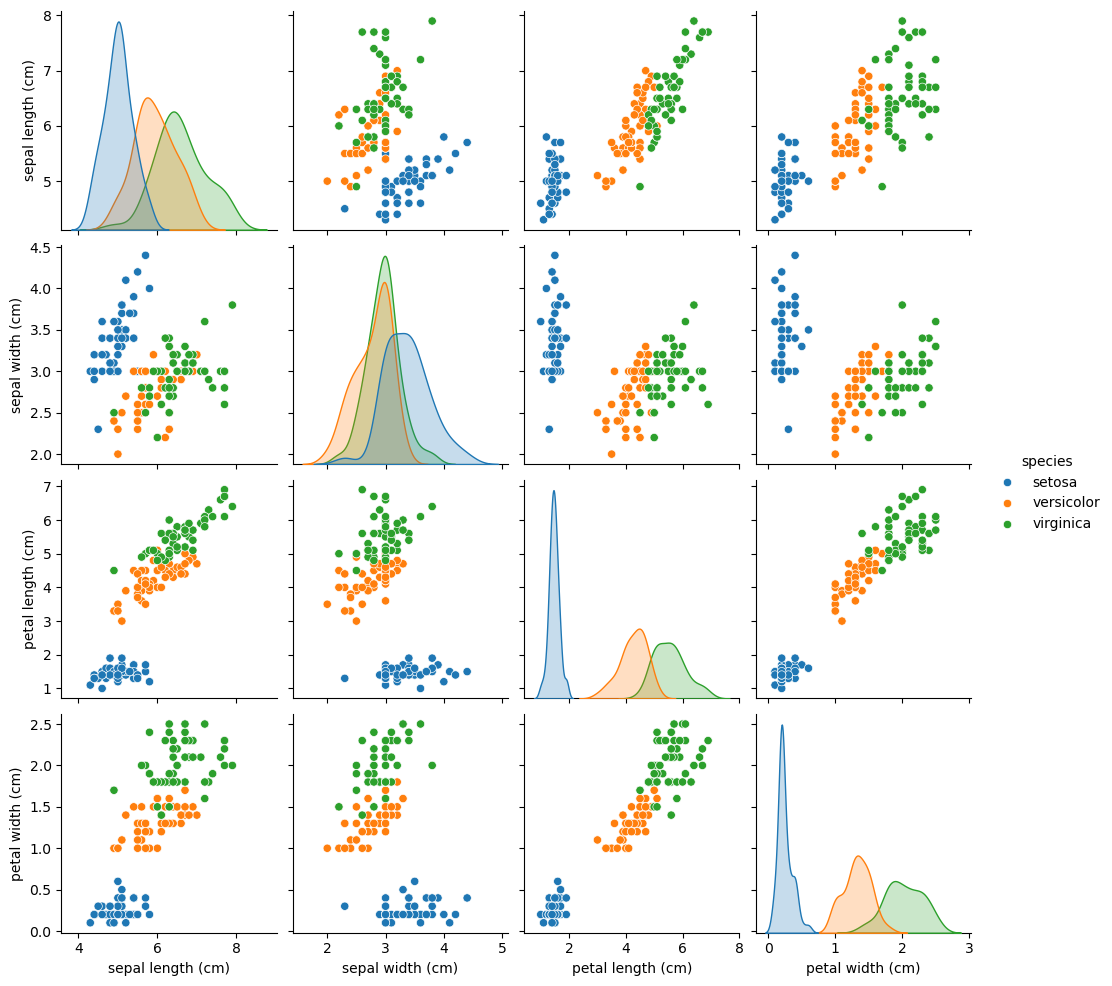

In [7]:
sns.pairplot(df, hue='species') 
plt.show() 

## Ответы на вопросы

### Какие способы обработки пропусков использовались?

- Для количественного признака пропуски заполнялись медианой. Медиана устойчива к выбросам и сохраняет распределение признака лучше, чем среднее значение.
- Для категориального признака пропуски заполнялись модой (наиболее частое значение). Данный подход выбран для категориальной переменной, поскольку среднее или медиана для нее не определены.

### Какие признаки будут использоваться для построения моделей?

Для построения моделей машинного обучения целесообразно использовать четыре исходных количественных признака, а в качестве целевой переменной использовать species.
На парных диаграммах хорошо видно, что классы (виды ирисов) почти линейно разделяются по признакам petal length и petal width, а признаки sepal length и sepal width дают дополнительную полезную информацию. Признак petal_size создан искусственно на основе petal length (cm), поэтому он дублирует информацию исходного количественного признака и его включение одновременно с petal length нецелесообразно.